# Análise Inicial de Dados - Tênis de Corrida RunRepeat

## 1. Compreensão dos Atributos

**Dataset:** 530 tênis de corrida extraídos do site RunRepeat  
**Período de coleta:** Novembro 2024  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [24]:
# Carregar dados
df = pd.read_csv('tenis_scraper_runrepeat/data/runrepeat_shoes_complete.csv')

print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dimensões: 530 linhas x 46 colunas


## 1.1 Visão Geral dos Dados

In [25]:
# Primeiras linhas do dataset
df.head()

,name,url,image,audience score,price,pace,arch support,weight lab weight brand,lightweight,drop lab drop brand,strike pattern,midsole softness,difference in midsole softness in cold,toebox durability,heel padding durability,outsole durability,breathability,heel stack,forefoot stack,drop,flexibility / stiffness (new method),flexibility / stiffness (old method),brand,audience_score,price_usd,drop_mm,weight,weight_grams,trail terrain,heel stack lab heel stack brand,midsole width - forefoot,midsole width - heel,outsole thickness,weight (g),drop (mm),flexibility of the shoe (n),flexibility of the shoe (freezer 20 min) (n),flexibility of the shoe (% of change),"longitudinal flexibility (1-5 scale, 5 being the stiffest)","torsional flexibility (1-5 scale, 5 being the stiffest)",flexibility of the shoe (freezer 1 hour) (n),"longitudinal flexibility (on a 0-5 scale, 0 being the stiffest)","torsional flexibility (on a 0-5 scale, 0 being the stiffest)",agility and responsiveness,outsole hardness,fuelcell supercomp pacer v2
0,ASICS Novablast 5,https://runrepeat.com/asics-novablast-5,https://cdn.runrepeat.com/storage/gallery/prod...,92 Superb!,$140,Daily runningTempo,Neutral,9 oz / 254g 9 oz / 255g,✗,7.4 mm 8.0 mm,HeelMid/forefoot,13.0 HA,Big,Bad,Decent,Good,Moderate,40.9 mm,33.5 mm,7.4 mm,11.2N,19.1N,ASICS,92.0,140.0,7.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Nike Vomero Plus,https://runrepeat.com/nike-vomero-plus,https://cdn.runrepeat.com/storage/gallery/prod...,91 Superb!,$180,Daily running,Neutral,10.2 oz / 289g 10.1 oz / 285g,NaN,9.6 mm 10.0 mm,HeelMid/forefoot,15.1 HA,Small,Decent,Good,Good,3,42.3 mm,32.7 mm,9.6 mm,19.8N,NaN,Nike,91.0,180.0,9.6,10.2 oz (289g),289.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Hoka Bondi 9,https://runrepeat.com/hoka-bondi-9,https://cdn.runrepeat.com/storage/gallery/prod...,90 Great!,$170,Daily running,Neutral,10.7 oz / 303g 10.5 oz / 297g,NaN,9.1 mm 5.0 mm,HeelMid/forefoot,25.1 HA,Small,Good,Good,Good,Moderate,41.3 mm,32.2 mm,9.1 mm,16.5N,30.6N,HOKA,90.0,170.0,9.1,10.7 oz (303g),303.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,New Balance Fresh Foam X More v5,https://runrepeat.com/new-balance-fresh-foam-x...,https://cdn.runrepeat.com/storage/gallery/prod...,87 Great!,$155,Daily running,Neutral,10.9 oz / 308g 10.7 oz / 303g,NaN,7.8 mm 4.0 mm,Mid/forefoot,8.6 HA,Normal,Decent,Decent,Good,Breathable,42.1 mm,34.3 mm,7.8 mm,18.1N,30.6N,New Balance,87.0,155.0,7.8,10.9 oz (308g),308.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Nike Vomero 18,https://runrepeat.com/nike-vomero-18,https://cdn.runrepeat.com/storage/gallery/prod...,91 Superb!,$150,Daily running,Neutral,10.5 oz / 298g 11.5 oz / 325g,NaN,13.9 mm 10.0 mm,Heel,15.0 HA,Small,Decent,Good,Decent,3,42.5 mm,28.6 mm,13.9 mm,16.0N,NaN,Nike,91.0,150.0,13.9,10.5 oz (298g),298.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Informações gerais
print("\nINFORMAÇÕES GERAIS DO DATASET")
print("="*100)
df.info()


INFORMAÇÕES GERAIS DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 46 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   name                                                             530 non-null    object 
 1   url                                                              530 non-null    object 
 2   image                                                            530 non-null    object 
 3   audience score                                                   521 non-null    object 
 4   price                                                            530 non-null    object 
 5   pace                                                             409 non-null    object 
 6   arch support                                                     530 non-null    object 
 7   weight lab we

## 1.2 Classificação dos Atributos

### Definições:

**Tipos de Atributos:**
- **Nominal:** Categorias sem ordem (ex: marca, cor)
- **Ordinal:** Categorias com ordem (ex: qualidade: ruim, bom, excelente)
- **Numérico Discreto:** Valores inteiros contáveis (ex: número de reviews)
- **Numérico Contínuo:** Valores reais em intervalo (ex: peso, preço)

**Escalas Numéricas:**
- **Intervalo:** Diferenças têm significado, mas razões não (ex: temperatura em Celsius)
- **Razão:** Zero absoluto, razões têm significado (ex: peso, altura)
- **Absoluta:** Contagens inteiras (ex: número de itens)

In [16]:
atributos_classificacao = [
    # Atributos Identificadores e URLs
    {
        'Atributo': 'name',
        'Traducao': 'nome',
        'Tipo': 'Nominal',
        'Domínio': 'Texto livre (nomes de produtos)',
        'Domínio Dinâmico': 'Sim',
        'Escala': 'N/A',
        'Completude': f"{(df['name'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Identificador único do produto. 530 valores únicos.'
    },
    {
        'Atributo': 'url',
        'Traducao': 'url',
        'Tipo': 'Nominal',
        'Domínio': 'URL válida (formato: https://runrepeat.com/...)',
        'Domínio Dinâmico': 'Sim',
        'Escala': 'N/A',
        'Completude': f"{(df['url'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Link para página do produto. Valores únicos.'
    },
    {
        'Atributo': 'image',
        'Traducao': 'imagem',
        'Tipo': 'Nominal',
        'Domínio': 'URL válida de imagem (CDN)',
        'Domínio Dinâmico': 'Sim',
        'Escala': 'N/A',
        'Completude': f"{(df['image'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'URL da imagem principal do produto.'
    },
    
    # Atributos de Avaliação
    {
        'Atributo': 'audience score',
        'Traducao': 'pontuação do público',
        'Tipo': 'Ordinal',
        'Domínio': 'Texto: "XX Category" (ex: "92 Superb!")',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Intervalo',
        'Completude': f"{(df['audience score'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Score de 0-100 com categoria qualitativa. 23 valores únicos.'
    },
    {
        'Atributo': 'audience_score',
        'Traducao': 'pontuação numérica do público',
        'Tipo': 'Numérico Contínuo',
        'Domínio': '[0, 100]',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Razão',
        'Completude': f"{(df['audience_score'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Versão numérica do score. Valor de referência zero.'
    },
    
    # Atributos de Preço
    {
        'Atributo': 'price',
        'Traducao': 'preço',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "$XXX"',
        'Domínio Dinâmico': 'Sim',
        'Escala': 'N/A',
        'Completude': f"{(df['price'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Preço em formato texto. 43 valores únicos.'
    },
    {
        'Atributo': 'price_usd',
        'Traducao': 'preço em USD',
        'Tipo': 'Numérico Contínuo',
        'Domínio': '[0, +∞) (valores reais positivos)',
        'Domínio Dinâmico': 'Sim',
        'Escala': 'Razão',
        'Completude': f"{(df['price_usd'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Preço em USD. Zero absoluto (gratuito). Razão tem significado (2x mais caro).'
    },
    
    # Atributos de Marca
    {
        'Atributo': 'brand',
        'Traducao': 'marca',
        'Tipo': 'Nominal',
        'Domínio': 'Texto (nomes de marcas)',
        'Domínio Dinâmico': 'Sim',
        'Escala': 'N/A',
        'Completude': f"{(df['brand'].notna().sum()/len(df)*100):.1f}%",
        'Observações': f'Fabricante do tênis. {df["brand"].nunique()} marcas diferentes.'
    },
    
    # Atributos de Uso/Tipo
    {
        'Atributo': 'pace',
        'Traducao': 'ritmo/uso',
        'Tipo': 'Ordinal',
        'Domínio': '{Daily running, Tempo, Racing, Walking, Hiking}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['pace'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Tipo de ritmo/uso recomendado. 5 categorias.'
    },
    {
        'Atributo': 'arch support',
        'Traducao': 'suporte ao arco',
        'Tipo': 'Ordinal',
        'Domínio': '{Neutral, Stability, Motion control}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['arch support'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Tipo de suporte ao arco do pé. 3 categorias ordenadas por nível de suporte.'
    },
    {
        'Atributo': 'strike pattern',
        'Traducao': 'padrão de pisada',
        'Tipo': 'Nominal',
        'Domínio': '{Heel, Mid/forefoot, HeelMid/forefoot}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['strike pattern'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Padrão de pisada recomendado. 3 categorias.'
    },
    {
        'Atributo': 'trail terrain',
        'Traducao': 'terreno de trilha',
        'Tipo': 'Ordinal',
        'Domínio': '{Light trail, Rugged terrain, Mountain/Ultra, etc}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['trail terrain'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Tipo de terreno (apenas para tênis de trail). Apenas 22.8% preenchido.'
    },
    
    # Atributos de Peso
    {
        'Atributo': 'weight',
        'Traducao': 'peso',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX oz (XXXg)"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['weight'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Peso em formato texto com múltiplas unidades.'
    },
    {
        'Atributo': 'weight_grams',
        'Traducao': 'peso em gramas',
        'Tipo': 'Numérico Contínuo',
        'Domínio': '(0, +∞) gramas',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Razão',
        'Completude': f"{(df['weight_grams'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Peso em gramas. Zero absoluto. Razão tem significado (2x mais pesado).'
    },
    {
        'Atributo': 'weight lab weight brand',
        'Traducao': 'peso laboratório vs. fabricante',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX oz / XXXg XX oz / XXXg"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['weight lab weight brand'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Comparação peso laboratório vs. fabricante. 475 valores únicos.'
    },
    {
        'Atributo': 'lightweight',
        'Traducao': 'leveza',
        'Tipo': 'Nominal',
        'Domínio': '{✗, NaN}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['lightweight'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Indicador binário de leveza. Apenas 45.7% preenchido.'
    },
    {
        'Atributo': 'weight (g)',
        'Traducao': 'peso (g)',
        'Tipo': 'Nominal',
        'Domínio': 'Texto numérico',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['weight (g)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Peso alternativo. Apenas 1.7% preenchido. Redundante com weight_grams.'
    },
    
    # Atributos de Drop
    {
        'Atributo': 'drop',
        'Traducao': 'drop',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX mm"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['drop'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Diferença de altura calcanhar-antepé em formato texto. 134 valores únicos.'
    },
    {
        'Atributo': 'drop_mm',
        'Traducao': 'drop em mm',
        'Tipo': 'Numérico Contínuo',
        'Domínio': '[0, +∞) milímetros',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Razão',
        'Completude': f"{(df['drop_mm'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Drop em mm. Zero significa "zero drop". Razão tem significado.'
    },
    {
        'Atributo': 'drop lab drop brand',
        'Traducao': 'drop laboratório vs. fabricante',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX mm XX mm"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['drop lab drop brand'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Comparação drop laboratório vs. fabricante. 313 valores únicos.'
    },
    {
        'Atributo': 'drop (mm)',
        'Traducao': 'drop (mm)',
        'Tipo': 'Numérico Contínuo',
        'Domínio': '[0, +∞) milímetros',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Razão',
        'Completude': f"{(df['drop (mm)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Drop alternativo. Apenas 1.7% preenchido. Redundante com drop_mm.'
    },
    
    # Atributos de Stack (Altura da Sola)
    {
        'Atributo': 'heel stack',
        'Traducao': 'altura do calcanhar',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX mm" ou "XX.X mm"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['heel stack'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Altura da sola no calcanhar em formato texto. 176 valores únicos.'
    },
    {
        'Atributo': 'forefoot stack',
        'Traducao': 'altura do antepé',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX mm" ou "XX.X mm"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['forefoot stack'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Altura da sola no antepé em formato texto. 177 valores únicos.'
    },
    {
        'Atributo': 'heel stack lab heel stack brand',
        'Traducao': 'altura do calcanhar laboratório vs. fabricante',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX.X mm XX.X mm"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['heel stack lab heel stack brand'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Comparação stack laboratório vs. fabricante. Apenas 22.8% preenchido.'
    },
    
    # Atributos de Maciez/Amortecimento
    {
        'Atributo': 'midsole softness',
        'Traducao': 'maciez da entressola',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX HA" ou "XX.X HA"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['midsole softness'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Dureza Shore A. Valores maiores = mais duro. 175 valores únicos.'
    },
    {
        'Atributo': 'difference in midsole softness in cold',
        'Traducao': 'diferença na maciez da entressola no frio',
        'Tipo': 'Ordinal',
        'Domínio': '{Small, Big, Huge, Medium, Moderate}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['difference in midsole softness in cold'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Mudança na maciez em temperatura fria. 5 categorias ordenadas.'
    },
    
    # Atributos de Flexibilidade
    {
        'Atributo': 'flexibility / stiffness (new method)',
        'Traducao': 'flexibilidade / rigidez (novo método)',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX N" ou "XX.X N"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['flexibility / stiffness (new method)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Rigidez em Newtons (novo método). 133 valores únicos. 58.7% preenchido.'
    },
    {
        'Atributo': 'flexibility / stiffness (old method)',
        'Traducao': 'flexibilidade / rigidez (método antigo)',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX N" ou "XX.X N"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['flexibility / stiffness (old method)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Rigidez em Newtons (método antigo). 242 valores únicos. 79.8% preenchido.'
    },
    {
        'Atributo': 'flexibility of the shoe (n)',
        'Traducao': 'flexibilidade do calçado (n)',
        'Tipo': 'Numérico Contínuo',
        'Domínio': '(0, +∞) Newtons',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Razão',
        'Completude': f"{(df['flexibility of the shoe (n)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Força necessária para dobrar. Apenas 1.7% preenchido.'
    },
    {
        'Atributo': 'flexibility of the shoe (freezer 20 min) (n)',
        'Traducao': 'flexibilidade do calçado (congelador 20 min) (n)',
        'Tipo': 'Numérico Contínuo',
        'Domínio': '(0, +∞) Newtons',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Razão',
        'Completude': f"{(df['flexibility of the shoe (freezer 20 min) (n)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Flexibilidade após congelamento. Apenas 1.5% preenchido.'
    },
    {
        'Atributo': 'flexibility of the shoe (freezer 1 hour) (n)',
        'Traducao': 'flexibilidade do calçado (congelador 1 hora) (n)',
        'Tipo': 'Numérico Contínuo',
        'Domínio': '(0, +∞) Newtons',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Razão',
        'Completude': f"{(df['flexibility of the shoe (freezer 1 hour) (n)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Flexibilidade após 1h congelamento. Apenas 0.2% preenchido.'
    },
    {
        'Atributo': 'flexibility of the shoe (% of change)',
        'Traducao': 'flexibilidade do calçado (% de mudança)',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX%" ou "-XX%"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['flexibility of the shoe (% of change)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Variação percentual na flexibilidade. Apenas 1.7% preenchido.'
    },
    {
        'Atributo': 'longitudinal flexibility (1-5 scale, 5 being the stiffest)',
        'Traducao': 'flexibilidade longitudinal (escala 1-5, 5 sendo o mais rígido)',
        'Tipo': 'Ordinal',
        'Domínio': '[1, 5] (escala discreta)',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Intervalo',
        'Completude': f"{(df['longitudinal flexibility (1-5 scale, 5 being the stiffest)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Flexibilidade longitudinal. Escala ordinal. Apenas 1.5% preenchido.'
    },
    {
        'Atributo': 'longitudinal flexibility (on a 0-5 scale, 0 being the stiffest)',
        'Traducao': 'flexibilidade longitudinal (escala 0-5, 0 sendo o mais rígido)',
        'Tipo': 'Ordinal',
        'Domínio': '[0, 5] (escala discreta)',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Intervalo',
        'Completude': f"{(df['longitudinal flexibility (on a 0-5 scale, 0 being the stiffest)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Flexibilidade longitudinal (escala invertida). Apenas 0.2% preenchido.'
    },
    {
        'Atributo': 'torsional flexibility (1-5 scale, 5 being the stiffest)',
        'Traducao': 'flexibilidade torsional (escala 1-5, 5 sendo o mais rígido)',
        'Tipo': 'Ordinal',
        'Domínio': '[1, 5] (escala discreta)',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Intervalo',
        'Completude': f"{(df['torsional flexibility (1-5 scale, 5 being the stiffest)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Flexibilidade torsional. Apenas 0.6% preenchido.'
    },
    {
        'Atributo': 'torsional flexibility (on a 0-5 scale, 0 being the stiffest)',
        'Traducao': 'flexibilidade torsional (escala 0-5, 0 sendo o mais rígido)',
        'Tipo': 'Ordinal',
        'Domínio': '[0, 5] (escala discreta)',
        'Domínio Dinâmico': 'Não',
        'Escala': 'Intervalo',
        'Completude': f"{(df['torsional flexibility (on a 0-5 scale, 0 being the stiffest)'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Flexibilidade torsional (escala invertida). Apenas 0.2% preenchido.'
    },
    
    # Atributos de Durabilidade
    {
        'Atributo': 'toebox durability',
        'Traducao': 'durabilidade da parte frontal',
        'Tipo': 'Ordinal',
        'Domínio': '{Bad, Decent, Good, Great, Excellent, Outstanding}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['toebox durability'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Durabilidade da parte frontal. 6 categorias ordenadas por qualidade.'
    },
    {
        'Atributo': 'heel padding durability',
        'Traducao': 'durabilidade do acolchoamento do calcanhar',
        'Tipo': 'Ordinal',
        'Domínio': '{Bad, Decent, Good, Great}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['heel padding durability'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Durabilidade do acolchoamento do calcanhar. 4 categorias ordenadas.'
    },
    {
        'Atributo': 'outsole durability',
        'Traducao': 'durabilidade da sola externa',
        'Tipo': 'Ordinal',
        'Domínio': '{Bad, Decent, Good, Great}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['outsole durability'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Durabilidade da sola externa. 4 categorias ordenadas.'
    },
    {
        'Atributo': 'outsole hardness',
        'Traducao': 'dureza da sola externa',
        'Tipo': 'Nominal',
        'Domínio': 'Texto livre',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['outsole hardness'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Dureza da sola. Apenas 0.4% preenchido.'
    },
    
    # Atributos de Respirabilidade
    {
        'Atributo': 'breathability',
        'Traducao': 'respirabilidade',
        'Tipo': 'Ordinal',
        'Domínio': '{Poor, Moderate, Good, Excellent, etc}',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['breathability'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Capacidade de ventilação. 9 valores únicos ordenados.'
    },
    
    # Atributos de Largura
    {
        'Atributo': 'midsole width - forefoot',
        'Traducao': 'largura da entressola - antepé',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX mm" ou "XXX mm"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['midsole width - forefoot'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Largura da entressola no antepé. Apenas 10.8% preenchido.'
    },
    {
        'Atributo': 'midsole width - heel',
        'Traducao': 'largura da entressola - calcanhar',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "XX mm"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['midsole width - heel'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Largura da entressola no calcanhar. Apenas 6.0% preenchido.'
    },
    
    # Atributos de Espessura
    {
        'Atributo': 'outsole thickness',
        'Traducao': 'espessura da sola externa',
        'Tipo': 'Nominal',
        'Domínio': 'Texto: "X.X mm"',
        'Domínio Dinâmico': 'Não',
        'Escala': 'N/A',
        'Completude': f"{(df['outsole thickness'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Espessura da sola externa. Apenas 2.1% preenchido.'
    },
    
    # Atributos Diversos/Esparsos
    {
        'Atributo': 'agility and responsiveness',
        'Traducao': 'agilidade e responsividade',
        'Tipo': 'Nominal',
        'Domínio': 'Texto livre',
        'Domínio Dinâmico': 'Sim',
        'Escala': 'N/A',
        'Completude': f"{(df['agility and responsiveness'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Avaliação de agilidade. Apenas 0.2% preenchido.'
    },
    {
        'Atributo': 'fuelcell supercomp pacer v2',
        'Traducao': 'fuelcell supercomp pacer v2',
        'Tipo': 'Nominal',
        'Domínio': 'Texto livre',
        'Domínio Dinâmico': 'Sim',
        'Escala': 'N/A',
        'Completude': f"{(df['fuelcell supercomp pacer v2'].notna().sum()/len(df)*100):.1f}%",
        'Observações': 'Atributo específico de produto. Apenas 0.2% preenchido. Erro de extração.'
    },
]

# Criar DataFrame
df_atributos = pd.DataFrame(atributos_classificacao)

# Exibir tabela
print("\nTABELA DE CLASSIFICAÇÃO DOS ATRIBUTOS")
print("="*120)
display(df_atributos)


TABELA DE CLASSIFICAÇÃO DOS ATRIBUTOS


,Atributo,Traducao,Tipo,Domínio,Domínio Dinâmico,Escala,Completude,Observações
0,name,nome,Nominal,Texto livre (nomes de produtos),Sim,N/A,100.0%,Identificador único do produto. 530 valores ún...
1,url,url,Nominal,URL válida (formato: https://runrepeat.com/...),Sim,N/A,100.0%,Link para página do produto. Valores únicos.
2,image,imagem,Nominal,URL válida de imagem (CDN),Sim,N/A,100.0%,URL da imagem principal do produto.
3,audience score,pontuação do público,Ordinal,"Texto: ""XX Category"" (ex: ""92 Superb!"")",Não,Intervalo,98.3%,Score de 0-100 com categoria qualitativa. 23 v...
4,audience_score,pontuação numérica do público,Numérico Contínuo,"[0, 100]",Não,Razão,98.3%,Versão numérica do score. Valor de referência ...
5,price,preço,Nominal,"Texto: ""$XXX""",Sim,N/A,100.0%,Preço em formato texto. 43 valores únicos.
6,price_usd,preço em USD,Numérico Contínuo,"[0, +∞) (valores reais positivos)",Sim,Razão,100.0%,Preço em USD. Zero absoluto (gratuito). Razão ...
7,brand,marca,Nominal,Texto (nomes de marcas),Sim,N/A,100.0%,Fabricante do tênis. 26 marcas diferentes.
8,pace,ritmo/uso,Ordinal,"{Daily running, Tempo, Racing, Walking, Hiking}",Não,N/A,77.2%,Tipo de ritmo/uso recomendado. 5 categorias.
9,arch support,suporte ao arco,Ordinal,"{Neutral, Stability, Motion control}",Não,N/A,100.0%,Tipo de suporte ao arco do pé. 3 categorias or...


## 1.3 Estatísticas de Completude dos Dados

In [17]:
# Calcular estatísticas de completude
completude = pd.DataFrame({
    'Atributo': df.columns,
    'Total': len(df),
    'Não-Nulos': df.notna().sum(),
    'Nulos': df.isna().sum(),
    'Completude (%)': (df.notna().sum() / len(df) * 100).round(1),
    'Valores Únicos': df.nunique()
})

completude = completude.sort_values('Completude (%)', ascending=False)

# remove a coluna 0
completude = completude.drop(columns=['Atributo'])

print("\nESTATÍSTICAS DE COMPLETUDE POR ATRIBUTO")
display(completude)




ESTATÍSTICAS DE COMPLETUDE POR ATRIBUTO


,Total,Não-Nulos,Nulos,Completude (%),Valores Únicos
name,530,530,0,100.0,530
url,530,530,0,100.0,530
image,530,530,0,100.0,530
price,530,530,0,100.0,43
weight lab weight brand,530,530,0,100.0,475
arch support,530,530,0,100.0,3
difference in midsole softness in cold,530,530,0,100.0,5
midsole softness,530,530,0,100.0,175
drop lab drop brand,530,530,0,100.0,313
strike pattern,530,530,0,100.0,3


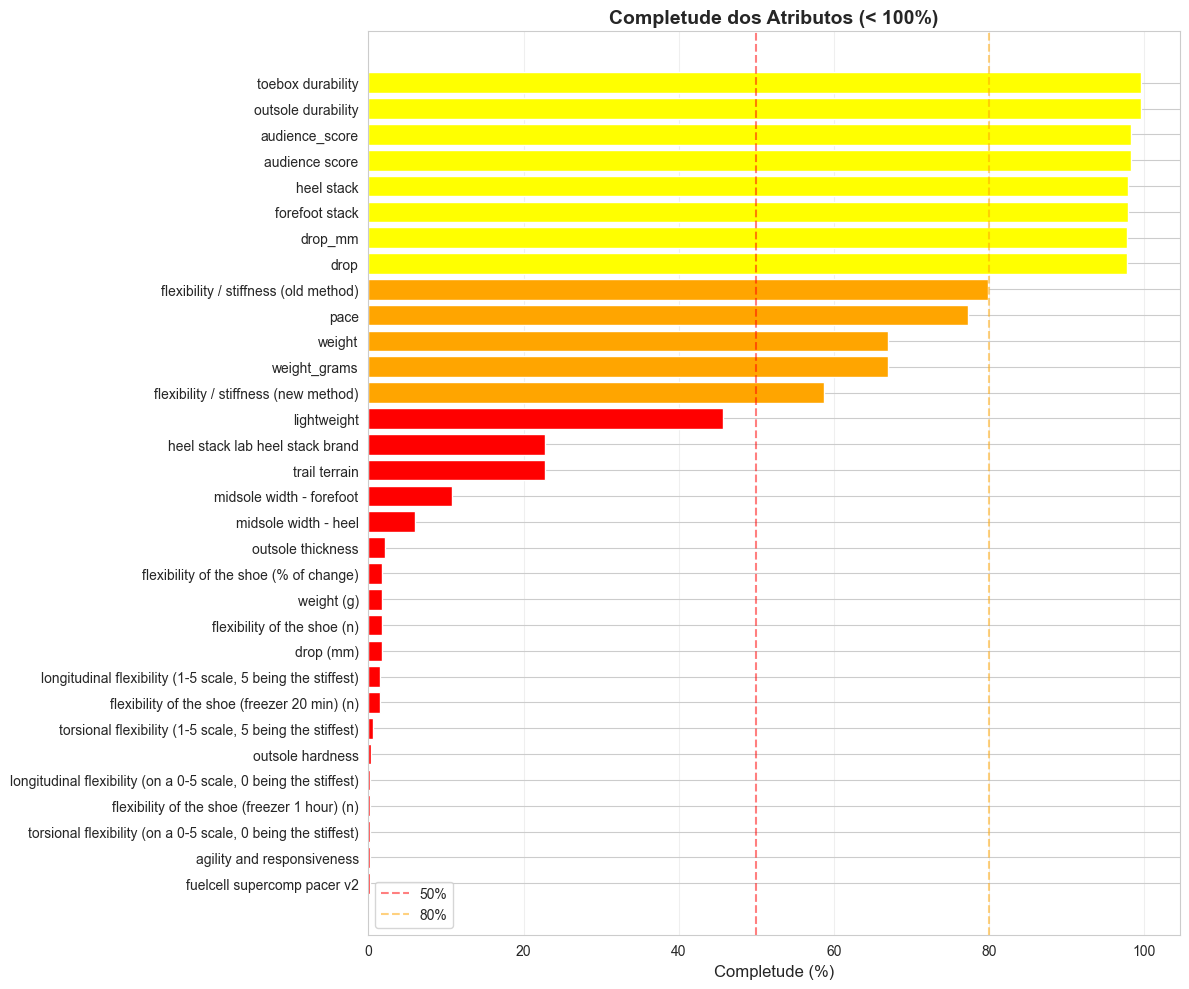


Atributos com menos de 50% de dados: 19
Atributos com 50-80% de dados: 5
Atributos com 80-100% de dados: 8
Atributos com 100% de dados: 14


In [18]:
# Visualizar completude
fig, ax = plt.subplots(figsize=(12, 10))

# Filtrar atributos com menos de 100% de completude
completude_parcial = completude[completude['Completude (%)'] < 100].sort_values('Completude (%)')

colors = ['red' if x < 50 else 'orange' if x < 80 else 'yellow' for x in completude_parcial['Completude (%)']]

ax.barh(completude_parcial['Atributo'], completude_parcial['Completude (%)'], color=colors)
ax.set_xlabel('Completude (%)', fontsize=12)
ax.set_title('Completude dos Atributos (< 100%)', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.axvline(x=80, color='orange', linestyle='--', alpha=0.5, label='80%')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAtributos com menos de 50% de dados: {len(completude[completude['Completude (%)'] < 50])}")
print(f"Atributos com 50-80% de dados: {len(completude[(completude['Completude (%)'] >= 50) & (completude['Completude (%)'] < 80)])}")
print(f"Atributos com 80-100% de dados: {len(completude[(completude['Completude (%)'] >= 80) & (completude['Completude (%)'] < 100)])}")
print(f"Atributos com 100% de dados: {len(completude[completude['Completude (%)'] == 100])}")

## 1.4 Análise por Tipo de Atributo


DISTRIBUIÇÃO POR TIPO DE ATRIBUTO
Nominal                  : 25 atributos (54.3%)
Ordinal                  : 13 atributos (28.3%)
Numérico Contínuo        :  8 atributos (17.4%)


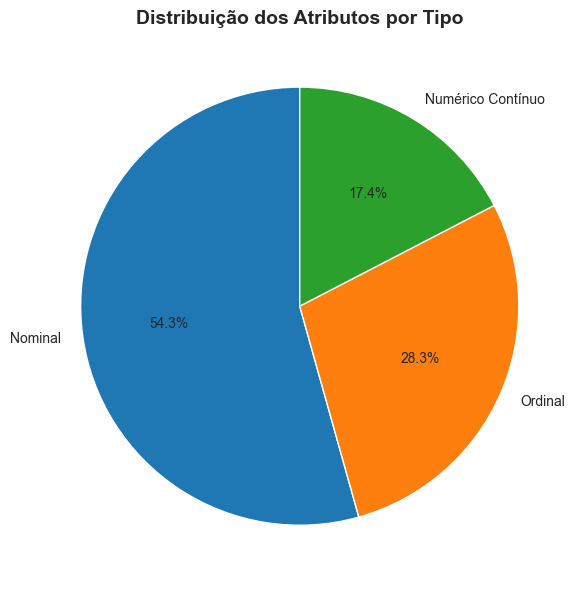

In [19]:
# Contar atributos por tipo
tipo_counts = df_atributos['Tipo'].value_counts()

print("\nDISTRIBUIÇÃO POR TIPO DE ATRIBUTO")
print("="*60)
for tipo, count in tipo_counts.items():
    print(f"{tipo:25s}: {count:2d} atributos ({count/len(df_atributos)*100:.1f}%)")

# Gráfico de pizza
fig, ax = plt.subplots(figsize=(10, 6))
ax.pie(tipo_counts.values, labels=tipo_counts.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Distribuição dos Atributos por Tipo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.5 Análise de Atributos Numéricos

In [20]:
# Filtrar apenas atributos numéricos
atributos_numericos = df_atributos[df_atributos['Tipo'].isin(['Numérico Contínuo', 'Numérico Discreto'])]

print("\nATRIBUTOS NUMÉRICOS E SUAS ESCALAS")
print("="*100)
display(atributos_numericos[['Atributo', 'Tipo', 'Escala', 'Domínio', 'Completude', 'Observações']])


ATRIBUTOS NUMÉRICOS E SUAS ESCALAS


,Atributo,Tipo,Escala,Domínio,Completude,Observações
4,audience_score,Numérico Contínuo,Razão,"[0, 100]",98.3%,Versão numérica do score. Valor de referência ...
6,price_usd,Numérico Contínuo,Razão,"[0, +∞) (valores reais positivos)",100.0%,Preço em USD. Zero absoluto (gratuito). Razão ...
13,weight_grams,Numérico Contínuo,Razão,"(0, +∞) gramas",67.0%,Peso em gramas. Zero absoluto. Razão tem signi...
18,drop_mm,Numérico Contínuo,Razão,"[0, +∞) milímetros",97.7%,"Drop em mm. Zero significa ""zero drop"". Razão ..."
20,drop (mm),Numérico Contínuo,Razão,"[0, +∞) milímetros",1.7%,Drop alternativo. Apenas 1.7% preenchido. Redu...
28,flexibility of the shoe (n),Numérico Contínuo,Razão,"(0, +∞) Newtons",1.7%,Força necessária para dobrar. Apenas 1.7% pree...
29,flexibility of the shoe (freezer 20 min) (n),Numérico Contínuo,Razão,"(0, +∞) Newtons",1.5%,Flexibilidade após congelamento. Apenas 1.5% p...
30,flexibility of the shoe (freezer 1 hour) (n),Numérico Contínuo,Razão,"(0, +∞) Newtons",0.2%,Flexibilidade após 1h congelamento. Apenas 0.2...


In [21]:
# Estatísticas descritivas dos principais atributos numéricos
principais_numericos = ['audience_score', 'price_usd', 'weight_grams', 'drop_mm']
colunas_existentes = [col for col in principais_numericos if col in df.columns]

if colunas_existentes:
    print("\nESTATÍSTICAS DESCRITIVAS DOS PRINCIPAIS ATRIBUTOS NUMÉRICOS")
    print("="*100)
    display(df[colunas_existentes].describe().round(2))


ESTATÍSTICAS DESCRITIVAS DOS PRINCIPAIS ATRIBUTOS NUMÉRICOS


,audience_score,price_usd,weight_grams,drop_mm
count,521.00,530.00,355.00,518.00
mean,86.78,153.09,273.95,8.32
std,3.77,43.88,38.83,3.16
min,70.00,65.00,128.00,0.00
25%,85.00,130.00,257.00,6.70
50%,88.00,150.00,278.00,8.70
75%,89.00,170.00,295.50,10.30
max,94.00,300.00,424.00,16.10


## 1.6 Análise de Domínios Dinâmicos

In [22]:
# Filtrar atributos com domínio dinâmico
dominios_dinamicos = df_atributos[df_atributos['Domínio Dinâmico'] == 'Sim']

print("\nATRIBUTOS COM DOMÍNIO DINÂMICO")
print("="*100)
print("Atributos cujos valores podem mudar ao longo do tempo (novos produtos, marcas, etc.)\n")
display(dominios_dinamicos[['Atributo', 'Tipo', 'Domínio', 'Observações']])

print(f"\nTotal: {len(dominios_dinamicos)} atributos com domínio dinâmico ({len(dominios_dinamicos)/len(df_atributos)*100:.1f}%)")


ATRIBUTOS COM DOMÍNIO DINÂMICO
Atributos cujos valores podem mudar ao longo do tempo (novos produtos, marcas, etc.)



,Atributo,Tipo,Domínio,Observações
0,name,Nominal,Texto livre (nomes de produtos),Identificador único do produto. 530 valores ún...
1,url,Nominal,URL válida (formato: https://runrepeat.com/...),Link para página do produto. Valores únicos.
2,image,Nominal,URL válida de imagem (CDN),URL da imagem principal do produto.
5,price,Nominal,"Texto: ""$XXX""",Preço em formato texto. 43 valores únicos.
6,price_usd,Numérico Contínuo,"[0, +∞) (valores reais positivos)",Preço em USD. Zero absoluto (gratuito). Razão ...
7,brand,Nominal,Texto (nomes de marcas),Fabricante do tênis. 26 marcas diferentes.
44,agility and responsiveness,Nominal,Texto livre,Avaliação de agilidade. Apenas 0.2% preenchido.
45,fuelcell supercomp pacer v2,Nominal,Texto livre,Atributo específico de produto. Apenas 0.2% pr...



Total: 8 atributos com domínio dinâmico (17.4%)


## 1.8 Exportar Tabela de Atributos

In [23]:
# Salvar tabela de atributos em CSV
df_atributos.to_csv('tabelas_exportadas/tabela_atributos_classificacao.csv', index=False, encoding='utf-8')
print("\nTabela de atributos exportada para: tabelas_exportadas/tabela_atributos_classificacao.csv")

# Salvar também a tabela de completude
completude.to_csv('tabelas_exportadas/tabela_completude_atributos.csv', index=False, encoding='utf-8')
print("Tabela de completude exportada para: tabelas_exportadas/tabela_completude_atributos.csv")


Tabela de atributos exportada para: tabelas_exportadas/tabela_atributos_classificacao.csv
Tabela de completude exportada para: tabelas_exportadas/tabela_completude_atributos.csv
